<span style="color:green; font-size:26px; font-weight:bold;">MODELO 4: </span>

<span style="color:green; font-size:33px; font-weight:bold;">RANDOM FOREST CLASSIFIER</span>

________________________________________________________________________________________________________________________________


### Justificación   

El algoritmo Random Forest constituye una extensión de los árboles de decisión basada en la construcción de múltiples árboles entrenados sobre diferentes muestras aleatorias de los datos. La predicción final se obtiene mediante la agregación de las predicciones individuales de todos los árboles del bosque.

Este enfoque permite reducir el sobreajuste que suele presentar un árbol de decisión aislado, mejorando la capacidad de generalización del modelo. Además, Random Forest es especialmente adecuado para conjuntos de datos de tipo encuesta, donde pueden existir relaciones complejas entre las variables explicativas.

Por estos motivos, se incorpora al estudio con el objetivo de evaluar si la combinación de múltiples árboles es capaz de mejorar la capacidad predictiva obtenida mediante la Regresión Logística y el Árbol de Decisión.


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
#Cargo nuevo dataset que utilizaré a a partir de ahora para trabajar con modelos de clasificación

df_mod_clas = pd.read_csv('../1_Data/processed_clas.csv')
df_mod_clas.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


In [16]:
# Variables predictoras
X = df_mod_clas.drop(
    columns=['Terr_hist', 'Sexo', 'Edad_interv', 'Lugar_nacim', 'Nacionalidad',
       'Nivel_estudios', 'Actividad', 'Tipo_hogar','Target_Satisfacc_Vida', 'Bienestar_alto']
)

# Variable objetivo
y = df_mod_clas['Bienestar_alto']

In [17]:
#separo en test y train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (5284, 10)
Dimensiones de y: (5284,)


In [18]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Bienestar_alto
1    0.536787
0    0.463213
Name: proportion, dtype: float64

Test:
Bienestar_alto
1    0.536424
0    0.463576
Name: proportion, dtype: float64


Es recomendable mantener el mismo criterio para todos los modelos de clasificación. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Creo y entreno el modelo

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=10
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
#Hago las predicciones

y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf

array([0, 1, 1, ..., 1, 1, 0], shape=(1057,))

In [22]:
#Metricas: 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.810
Precision: 0.808
Recall   : 0.847
F1-score : 0.827


La métricas de evaluación empeoran sensiblemente frente a las obtenidas en la regresión lineal.
La accuracy es de 0,728 pierde 9 puntos porcentuales frente a la regresión logística. El recall es de 0,72, lo que significa que identifica únicamente el 72,3% de las personas de bienestar alto frente al 84% de la regresión logística. El F1-score baja en 0,09 puntos.

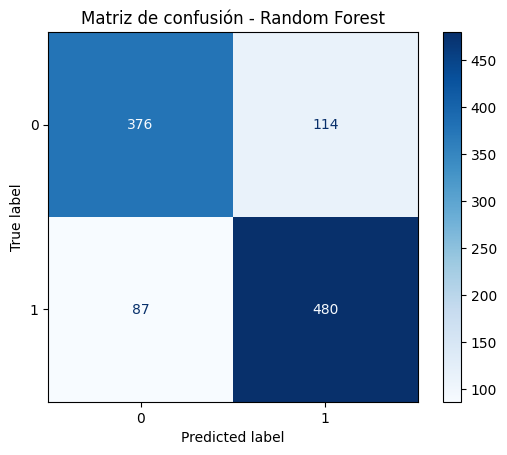

In [23]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues'
)

plt.title('Matriz de confusión - Random Forest')
plt.show()

La matriz de confusión refuerza aún más la conclusión de que el Decision Tree no está funcionando tan bien como la Regresión Logística. Los falsos negativos aumentan en un 72%, caída que se refleja en el peor resultado arrojado por el recall (0,72%). Los falsos positivos también empeoran, lo que provoca la caídsa de la precision (0,758 frente a 0,819).

In [24]:
#Importancia de las variables:

importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importancias_rf.sort_values(
    by='Importancia',
    ascending=False
)

,Variable,Importancia
0,Satisf_relac_pers,0.245729
1,Sentido_propia_vida,0.172163
2,Satisf_econom_domest,0.094677
5,Satisf_tiempo_disp,0.082191
4,Satisf_vivienda,0.081462
3,Valor_Estado_animo,0.078197
9,Confianza_poderes_pub,0.075126
8,Confianza_personas,0.069729
6,Satisf_viv_y_entorno,0.053954
7,Salud_percibida,0.046772


### Evaluación del modelo Random Forest Classifier

El modelo Random Forest obtuvo un accuracy de 0,810, una precision de 0,808, un recall de 0,847 y un F1-score de 0,827. Estos resultados sitúan su rendimiento en niveles muy similares a los alcanzados por la Regresión Logística y el Árbol de Decisión podado.

La matriz de confusión muestra que el modelo clasifica correctamente 376 individuos pertenecientes al grupo de menor bienestar y 480 individuos pertenecientes al grupo de bienestar elevado. Asimismo, se observan 114 falsos positivos y 87 falsos negativos.

Comparado con la Regresión Logística, el Random Forest consigue identificar un mayor número de individuos con bienestar elevado, lo que se refleja en un recall ligeramente superior (0,847 frente a 0,840). Sin embargo, esta mejora se produce a costa de un incremento de los falsos positivos, reduciendo ligeramente la precisión del modelo.

En términos globales, el F1-score obtenido (0,827) resulta prácticamente equivalente al alcanzado por la Regresión Logística (0,829), por lo que no se observan mejoras significativas derivadas del uso de un modelo más complejo. Estos resultados sugieren que la información predictiva contenida en las variables seleccionadas puede ser capturada eficazmente mediante modelos más simples e interpretables.


Ante los peores resultados obtenidos por el árbol de decisión, hago una prueba reduciendo la profundidad máxima del árbol a 4 niveles, con el objetivo de valorar si se está produciendo un overfitting que dificulta una adecuada generalización: 

In [27]:
#Vuelvo a entrenar el modelo limitando el riesgo de sobreajuste
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=10
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [29]:
#Hago las predicciones

y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf

array([0, 1, 1, ..., 1, 1, 0], shape=(1057,))

In [33]:
#Metricas: 

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.825
Precision: 0.808
Recall   : 0.884
F1-score : 0.844


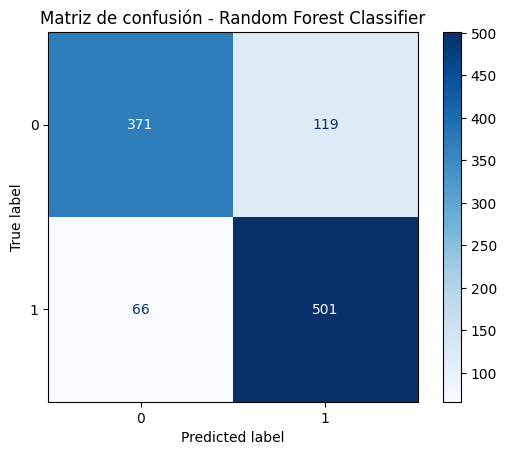

In [34]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues'
)

plt.title('Matriz de confusión - Random Forest Classifier')
plt.show()

Interpretación de las métricas:

El accuracy es el mayor alcanzado por el momento (0,825), y aunque el incremento es pequeño, ya sitúa a Random Forest como el mejor modelo en clasificación global.

Respecto al recall, el modelo identifica correctamente casi el 88,4% de las personas con bienestar alto. Es una mejora muy considerable.

Y el F1-score también mejora, hasta el 0,844, que ya es suficientemente relevante como para justificar la elección del modelo.

El Random Forest por defecto no mejoraba a la Regresión Logística. Sin embargo, al limitar la complejidad de los árboles, el modelo generaliza mejor.

La matriz de confusión aporta un matiz importante, y además refuerza aún más la candidatura del Random Forest ajustado como mejor modelo: reduce muchísimo los falsos negativos (y eso es precisamente lo que hace que el Recall suba hasta 0,884). Por el contrario, los falsos positivos aumentan, por eso la Precision baja ligeramente (0,808).

Disyuntiva: 
- Si el objetivo es detectar personas con bienestar elevado, el Random Forest es claramente mejor, porque deja escapar menos casos. 
- Si el objetivo es evitar clasificar incorrectamente a personas como de bienestar alto, la Logistic Regression es ligeramente mejor, porque genera menos falsas alarmas.

¿Qué priorizamos? 

Aunque la Regresión Logística ofrece una solución sencilla e interpretable con un rendimiento notable, el modelo Random Forest ajustado presenta la mejor capacidad predictiva global. Su principal fortaleza reside en la elevada sensibilidad mostrada para identificar correctamente a los individuos con altos niveles de bienestar, lo que se traduce en un Recall del 88,4% y un F1-score del 84,4%, superiores a los obtenidos por el resto de modelos evaluados.

Aunque en este estudio se ha definido como clase positiva a los individuos con elevados niveles de bienestar subjetivo, una posible línea futura de investigación consistiría en reformular el problema para identificar específicamente a las personas con riesgo de presentar niveles insuficientes de bienestar. Este enfoque permitiría orientar el modelo hacia aplicaciones preventivas en ámbitos como la salud pública o la gestión del bienestar organizacional, priorizando métricas como el Recall con el objetivo de minimizar los casos no detectados.